Grafico / esempio di vantaggio vae: probabilmente su 4 qubit

finestra di sample in cui:

fidelity train è piu bassa di fidelity ricostruita, grafico deltadist train vs vae gen (quello rifatto n volte)

studio di "scalabilità"? fidelity vs N vs N qubit (fino a 8-10(?)), anche solo singola run

In this notebook, we present an analysis of our Variational Autoencoder (VAE) method for reconstructing the probability distribution of POVM outcomes for a given quantum state.

We focus on the 4-qubit GHZ state because its larger outcome space ($4^N = 256$ possible outcomes) provides a first meaningful example of an interesting use case for generative modeling via VAEs.

We evaluate the classical fidelity as a function of the number of training samples ($N_{\text{train}}$) used to fit the VAE, benchmarking its denoising performance and identifying the regime of interest where this approach offers a clear advantage over direct empirical distribution.

[We deeply analize the differences in probability reconstruction ...]

Finally, we provide a scalability analysis up to an 8-qubit system. As an illustrative example, we briefly demonstrate how the VAE framework successfully scales to higher-dimensional Hilbert spaces by evaluating the classical fidelity against the number of training samples for systems up to $N=8$ qubits ($4^8 = 65,536$ outcomes).

#### Colab setup

In [ ]:
# --- drive mount to access the shared drive repo ---
# (only for using colab GPUs)
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# lib src folder
import sys
sys.path.append('/content/drive/MyDrive/statistical-qst-vae/statistical-qst-vae/src')

# Import

In [18]:
# general import:
import sys
import time
import os
import gc
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [19]:
# quantum import:
from qiskit import QuantumCircuit
from qiskit.quantum_info import DensityMatrix
from qiskit.visualization import plot_state_city, plot_state_hinton, plot_state_qsphere

In [20]:
# ML import:
import tensorflow as tf
import keras
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
import sklearn
from sklearn.model_selection import train_test_split

In [21]:
# custom helper and libraries:
sys.path.append('../src')
from povm_sampling import *
from statesprep import *
from vae import *
from plots import *
from utils import *
from mle import *

In [14]:
PROJECT_ROOT = Path.cwd().parent
RESULTS_ROOT = PROJECT_ROOT / "results"

In [30]:
qc = create_ghz_state(4)
rho = DensityMatrix(qc)
P_exact = povm_probability_efficient(rho.data, 4)
outcomes = list(P_exact.keys())  

In [ ]:
N_SAMPLES = [300, 500, 1000, 2000, 5000, 10000]
N_QUBITS = 4

# geometria (latent_dim, hidden, N_GEN) per numero di qubit
CFG = {
    #3: dict(latent_dim=16,  hidden=96,  batch_size=100, N_GEN=20000),
    4: dict(latent_dim=32,  hidden=128,  batch_size=200, N_GEN=100000),
    #5: dict(latent_dim=64,  hidden=224,  batch_size=500, N_GEN=4**5 * 500),
    #6: dict(latent_dim=256, hidden=1280, batch_size=600, N_GEN=4**6 * 500),
    #7: dict(latent_dim=512, hidden=1504, batch_size=800, N_GEN=4**7 * 500),
    #8: dict(latent_dim=512, hidden=2560, batch_size=1000, N_GEN=4**8 * 500),
}

for i in range(20):
    # accumulo i risultati per il plot finale: una curva per ogni numero di qubit
    results = {"n_samples": [], "Fc": [], "Fc_train": []}

    # GHZ esatto + distribuzione POVM vera
    qc = create_ghz_state(N_QUBITS)
    rho = DensityMatrix(qc)
    P_exact = povm_probability_efficient(rho.data, N_QUBITS)
    outcomes = list(P_exact.keys())            # ricalcolato per ogni q (era un bug: restava a 3 qubit)

    # run drive path : results/vae_analysis
    drive_path = RESULTS_ROOT / 'vae_analysis' / "run_{}".format(i+1)

    for n in N_SAMPLES:
        print(f"\n=== N_QUBITS={N_QUBITS}   N_SAMPLES={n} ===")
        n_samples = n

        seed = np.random.seed()
        # campiona la distribuzione e prepara i dati
        sample = sample_povm(P_exact, n_samples=n_samples, seed=seed)
        onehot_sample = samples_to_onehot(sample, N_QUBITS)
        X_train, X_test = train_test_split(onehot_sample, test_size=0.2, random_state=42)

        cfg = CFG[N_QUBITS]
        latent_dim, hidden, batch_size, N_GEN = cfg["latent_dim"], cfg["hidden"], cfg["batch_size"], cfg["N_GEN"]

        vae = VAE(n_qubits=N_QUBITS, latent_dim=latent_dim, hidden=hidden)
        vae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))
        vae.build(input_shape=(None, 4 * N_QUBITS))  # input_shape=(None, 4 * n_qubits) per one-hot encoding
        model = vae

        WARMUP = 40   # epoche di warm-up della KL (0 -> beta_max)
        callbacks = [
            KLWarmup(beta_max=0.85, warmup_epochs=WARMUP),
            EarlyStopping(monitor='reconstruction_loss', mode='min',
                            patience=40, restore_best_weights=True, start_from_epoch=WARMUP),
        ]

        history = model.fit(
            X_train, X_train,
            epochs=500,
            batch_size=batch_size,
            validation_data=(X_test, X_test),
            callbacks=callbacks,
            verbose=0,
        )

        # save results
        run_dir, checkpoint_path, history_path = set_up_training(experiment_id='vae_training_q{}_n{}'.format(N_QUBITS, n), drive_path = drive_path)
        model.save_weights(checkpoint_path)
        pd.DataFrame(history.history).to_csv(history_path, index=False)

        # campiona dal VAE e calcola le metriche vs la distribuzione esatta
        P_vae   = vae.predict_dist(n_samples=N_GEN, batch_size=50_000)
        P_train = samples_to_empirical_dist(onehot_to_samples(X_train, N_QUBITS), N_QUBITS)

        Fc        = classical_fidelity(P_vae,   P_exact)
        Fc_train  = classical_fidelity(P_train, P_exact)

        # Print with minimal informations
        print(f"  Fidelity classica VAE vs esatta : {Fc:.4f}   <- MODELLO")
        print(f"  Fidelity classica training vs esatta : {Fc_train:.4f}   <- TETTO")

        # salvo la fidelity classica per il plot al variare di N_SAMPLES e N_QUBITS
        # (atteso: cresce con n_samples, cala con n_qubits)
        results["n_samples"].append(n)
        results["Fc"].append(Fc)
        results["Fc_train"].append(Fc_train)

    print("\nRESULTS:", results)

    results_df = pd.DataFrame(results)

    # Save the results to a CSV file for later analysis and plotting PROJECT_ROOT
    results_df.to_csv(drive_path / "4q_vae_advantage.csv", index=False)


=== N_QUBITS=4   N_SAMPLES=300 ===
All saved in: /Users/riccardoruggeri/project-sda/statistical-qst-vae/results/vae_analysis/run_1/vae_training_q4_n300_0616_1129
  Fidelity classica VAE vs esatta : 0.9562   <- MODELLO
  Fidelity classica training vs esatta : 0.8371   <- TETTO

=== N_QUBITS=4   N_SAMPLES=500 ===
All saved in: /Users/riccardoruggeri/project-sda/statistical-qst-vae/results/vae_analysis/run_1/vae_training_q4_n500_0616_1129
  Fidelity classica VAE vs esatta : 0.9715   <- MODELLO
  Fidelity classica training vs esatta : 0.8854   <- TETTO

=== N_QUBITS=4   N_SAMPLES=1000 ===
All saved in: /Users/riccardoruggeri/project-sda/statistical-qst-vae/results/vae_analysis/run_1/vae_training_q4_n1000_0616_1129
  Fidelity classica VAE vs esatta : 0.9653   <- MODELLO
  Fidelity classica training vs esatta : 0.9487   <- TETTO

=== N_QUBITS=4   N_SAMPLES=2000 ===
All saved in: /Users/riccardoruggeri/project-sda/statistical-qst-vae/results/vae_analysis/run_1/vae_training_q4_n2000_0616_1129

In [ ]:
# -- load --
N_RUNS = 20

runs = []
for i in range(1, N_RUNS + 1):
    csv_path = RESULTS_ROOT / 'vae_analysis' / f"run_{i}" / "4q_vae_advantage.csv"
    df_i = pd.read_csv(csv_path)
    df_i["run"] = i
    runs.append(df_i)
df = pd.concat(runs, ignore_index=True)

# -- save run into unique csv --
df.to_csv(f'VAE_analysis/VAE_results_advantage_allN_B20.csv', index=False)
print("\n Saved!\t N_rows:", len(df))


 Saved!	 N_rows: 120


,n_samples,Fc_mean,Fc_std,Fc_train_mean,Fc_train_std
0,300,0.952682,0.005225,0.804984,0.014231
1,500,0.960685,0.006929,0.881670,0.008555
2,1000,0.965931,0.004856,0.940766,0.005345
3,2000,0.975116,0.005598,0.973759,0.002745
4,5000,0.983295,0.003860,0.991311,0.000778
5,10000,0.987708,0.001449,0.995908,0.000364


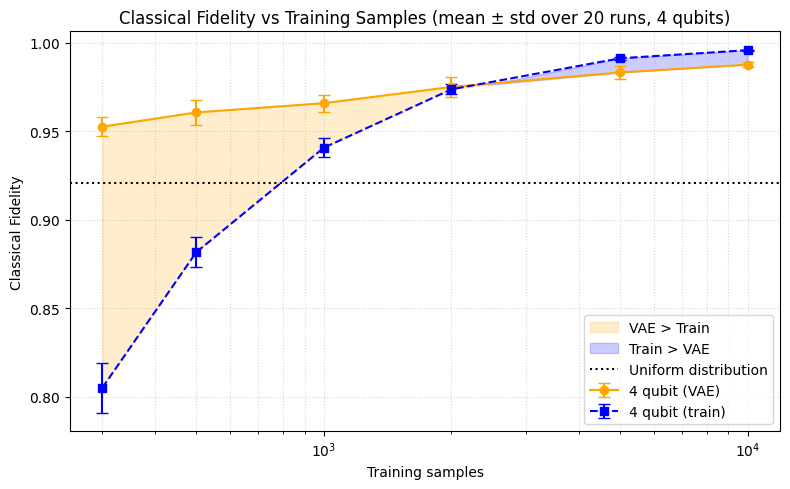

In [ ]:
# Carica i risultati di run_1 ... run_N, calcola media e std della fidelity
# classica su tutte le run e plotta F_c vs N_SAMPLES con barre d'errore,
# una curva per ogni numero di qubit.
N_RUNS = 20
P_unif = {o: 1.0 / len(outcomes) for o in outcomes}

# Concatena i CSV di tutte le run in un unico DataFrame
runs = []
for i in range(1, N_RUNS + 1):
    csv_path = RESULTS_ROOT / f"run_{i}" / "4q_vae_advantage.csv"
    df_i = pd.read_csv(csv_path)
    df_i["run"] = i
    runs.append(df_i)
all_runs = pd.concat(runs, ignore_index=True)

# Media e deviazione standard di Fc (e Fc_train) sulle run, per ogni (n_qubits, n_samples)
stats = (
    all_runs
    .groupby(["n_samples"])
    .agg(Fc_mean=("Fc", "mean"), Fc_std=("Fc", "std"),
         Fc_train_mean=("Fc_train", "mean"), Fc_train_std=("Fc_train", "std"))
    .reset_index()
)

# Plot: fidelity media vs N_SAMPLES con barre d'errore (std), una curva per numero di qubit
plt.figure(figsize=(8, 5))

sub = stats.sort_values("n_samples")
plt.errorbar(sub["n_samples"], sub["Fc_mean"], yerr=sub["Fc_std"],
                fmt='-o', color='orange', capsize=4, label=f'4 qubit (VAE)')
plt.errorbar(sub["n_samples"], sub["Fc_train_mean"], yerr=sub["Fc_train_std"],
                fmt='--s', color='blue', capsize=4, label=f'4 qubit (train)')

# Fill between: train classical fidelity and VAE classical fidelity
# Orange fill when VAE fidelity is higher than train fidelity, blue fill otherwise
plt.fill_between(sub["n_samples"], sub["Fc_mean"], sub["Fc_train_mean"],
                 where=sub["Fc_mean"] >= sub["Fc_train_mean"],
                 interpolate=True, color='orange', alpha=0.2, label='VAE > Train')
plt.fill_between(sub["n_samples"], sub["Fc_mean"], sub["Fc_train_mean"],
                 where=sub["Fc_mean"] < sub["Fc_train_mean"],
                 interpolate=True, color='blue', alpha=0.2, label='Train > VAE')


plt.axhline(y=classical_fidelity(P_unif, P_exact), color='black', linestyle=':', label='Uniform distribution')
plt.xscale('log')
plt.xlabel('Training samples')
plt.ylabel('Classical Fidelity')
plt.title(f'Classical Fidelity vs Training Samples (mean ± std over {N_RUNS} runs, 4 qubits)')
plt.grid(True, which='both', ls=':', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "results" / "classical_fidelity_vs_samples.svg")

stats

Dati caricati correttamente! N_rows: 120


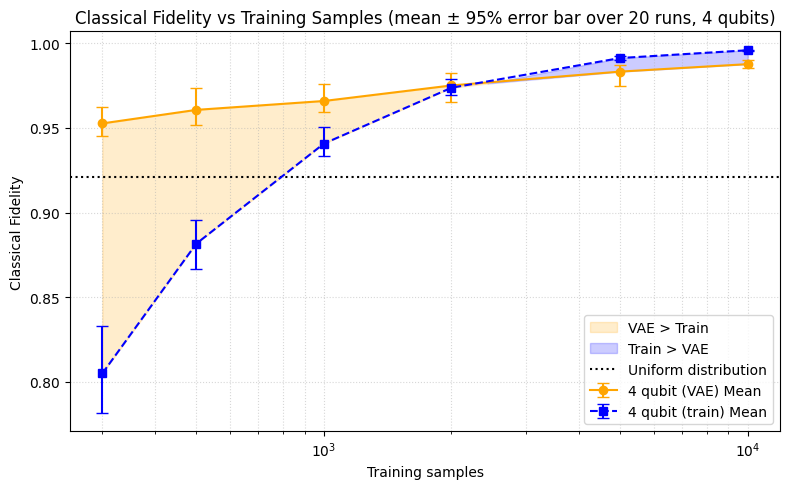

In [ ]:
# --- load ---
csv_path = 'VAE_analysis/VAE_results_advantage_allN_B20.csv'
df = pd.read_csv(csv_path)

print(f"file loaded! N_rows: {len(df)}")

N_RUNS = df['run'].nunique() 

# ==========================================
# 2. STATISTICAL AGGREGATION (95% PERCENTILES)
# ==========================================
P_unif = {o: 1.0 / len(outcomes) for o in outcomes}

# Ordiniamo il dataframe per n_samples prima di raggruppare
df_sorted = df.sort_values("n_samples")
n_values = sorted(df_sorted.n_samples.unique())

# Raggruppiamo per n_samples
g_fc = df_sorted.groupby("n_samples")["Fc"]
g_fc_train = df_sorted.groupby("n_samples")["Fc_train"]

# Medie
fc_mean = g_fc.mean().values
fc_train_mean = g_fc_train.mean().values

# Calcolo delle distanze asimmetriche per le barre d'errore (limite inferiore, limite superiore)
# yerr deve contenere: [ [media - q_0.025], [q_0.975 - media] ]
fc_err_below = fc_mean - g_fc.quantile(0.025).values
fc_err_above = g_fc.quantile(0.975).values - fc_mean
yerr_fc = np.vstack([fc_err_below, fc_err_above])

fc_train_err_below = fc_train_mean - g_fc_train.quantile(0.025).values
fc_train_err_above = g_fc_train.quantile(0.975).values - fc_train_mean
yerr_fc_train = np.vstack([fc_train_err_below, fc_train_err_above])

# ==========================================
# 3. PLOT GENERATION
# ==========================================
plt.figure(figsize=(8, 5))

# Plot con barre d'errore asimmetriche al 95% basate sui percentili
plt.errorbar(n_values, fc_mean, yerr=yerr_fc,
             fmt='-o', color='orange', capsize=4, label='4 qubit (VAE) Mean')

plt.errorbar(n_values, fc_train_mean, yerr=yerr_fc_train,
             fmt='--s', color='blue', capsize=4, label='4 qubit (train) Mean')

# Fill between: train classical fidelity and VAE classical fidelity
# Orange fill when VAE fidelity is higher than train fidelity, blue fill otherwise
plt.fill_between(n_values, fc_mean, fc_train_mean,
                 where=(fc_mean >= fc_train_mean),
                 interpolate=True, color='orange', alpha=0.2, label='VAE > Train')

plt.fill_between(n_values, fc_mean, fc_train_mean,
                 where=(fc_mean < fc_train_mean),
                 interpolate=True, color='blue', alpha=0.2, label='Train > VAE')

# --- Elementi di Contorno e Salvataggio ---
plt.axhline(y=classical_fidelity(P_unif, P_exact), color='black', linestyle=':', label='Uniform distribution')
plt.xscale('log')
plt.xlabel('Training samples')
plt.ylabel('Classical Fidelity')
plt.title(f'Classical Fidelity vs Training Samples (mean ± 95% error bar over {N_RUNS} runs, 4 qubits)')
plt.grid(True, which='both', ls=':', alpha=0.5)
plt.legend()
plt.tight_layout()

# plt.savefig(PROJECT_ROOT / "results" / "classical_fidelity_vs_samples.svg")
plt.show()

In [24]:
N_SAMPLES = [5000, 10000, 20000, 50000]
N_QUBITS = [4, 6, 8]

# geometria (latent_dim, hidden, N_GEN) per numero di qubit
CFG = {
    #3: dict(latent_dim=16,  hidden=96,  batch_size=100, N_GEN=20000),
    4: dict(latent_dim=32,  hidden=128,  batch_size=200, N_GEN=100000),
    #5: dict(latent_dim=64,  hidden=224,  batch_size=500, N_GEN=4**5 * 500),
    6: dict(latent_dim=256, hidden=1280, batch_size=600, N_GEN=4**6 * 500),
    #7: dict(latent_dim=512, hidden=1504, batch_size=800, N_GEN=4**7 * 500),
    8: dict(latent_dim=512, hidden=2560, batch_size=1000, N_GEN=4**7 * 500),
}
# accumulo i risultati per il plot finale: una curva per ogni numero di qubit
results = {q: {"n_samples": [], "Fc": [], "Fc_train": []} for q in N_QUBITS}

for q in N_QUBITS:
    # GHZ esatto + distribuzione POVM vera
    qc = create_ghz_state(q)
    rho = DensityMatrix(qc)
    P_exact = povm_probability_efficient(rho.data, q)
    outcomes = list(P_exact.keys())            # ricalcolato per ogni q (era un bug: restava a 3 qubit)

    for n in N_SAMPLES:
        print(f"\n=== N_QUBITS={q}   N_SAMPLES={n} ===")
        n_samples = n

        seed = np.random.seed(42 + n + q)  # seed diverso per ogni combinazione di n e q, ma fisso tra le run
        # campiona la distribuzione e prepara i dati
        sample = sample_povm(P_exact, n_samples=n_samples, seed=seed)
        onehot_sample = samples_to_onehot(sample, q)
        X_train, X_test = train_test_split(onehot_sample, test_size=0.2, random_state=42)

        cfg = CFG[q]
        latent_dim, hidden, batch_size, N_GEN = cfg["latent_dim"], cfg["hidden"], cfg["batch_size"], cfg["N_GEN"]

        vae = VAE(n_qubits=q, latent_dim=latent_dim, hidden=hidden)
        vae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))
        vae.build(input_shape=(None, 4 * q))
        model = vae

        WARMUP = 40   # epoche di warm-up della KL (0 -> beta_max)
        callbacks = [
            KLWarmup(beta_max=0.85, warmup_epochs=WARMUP),
            EarlyStopping(monitor='reconstruction_loss', mode='min',
                            patience=40, restore_best_weights=True, start_from_epoch=WARMUP),
        ]

        history = model.fit(
            X_train, X_train,
            epochs=500,
            batch_size=batch_size,
            validation_data=(X_test, X_test),
            callbacks=callbacks,
            verbose=0,
        )

        # save results
        drive_path = RESULTS_ROOT / "run_q{}_n{}".format(q, n)
        run_dir, checkpoint_path, history_path = set_up_training(experiment_id='vae_training_q{}_n{}'.format(q, n), drive_path = drive_path)
        model.save_weights(checkpoint_path)
        pd.DataFrame(history.history).to_csv(history_path, index=False)

        # campiona dal VAE e calcola le metriche vs la distribuzione esatta
        P_vae   = vae.predict_dist(n_samples=N_GEN, batch_size=50_000)
        P_train = samples_to_empirical_dist(onehot_to_samples(X_train, q), q)

        Fc        = classical_fidelity(P_vae,   P_exact)
        Fc_train  = classical_fidelity(P_train, P_exact)

        # Print with minimal informations
        print(f"  Classical Fidelity VAE vs exact: {Fc:.4f}   <- MODEL")
        print(f"  Classical Fidelity training vs exact: {Fc_train:.4f}   <- BASELINE")

        # salvo la fidelity classica per il plot al variare di N_SAMPLES e N_QUBITS
        # (atteso: cresce con n_samples, cala con n_qubits)
        results[q]["n_samples"].append(n)
        results[q]["Fc"].append(Fc)
        results[q]["Fc_train"].append(Fc_train)

    print("\nRESULTS:", results)

# Save results to a CSV file for later analysis and plotting
results_df = pd.DataFrame({
    "n_qubits": np.repeat(N_QUBITS, len(N_SAMPLES)),
    "n_samples": np.tile(N_SAMPLES, len(N_QUBITS)),
    "Fc": [results[q]["Fc"][i] for q in N_QUBITS for i in range(len(N_SAMPLES))],
    "Fc_train": [results[q]["Fc_train"][i] for q in N_QUBITS for i in range(len(N_SAMPLES))],
})

# Save the results to a CSV file for later analysis and plotting PROJECT_ROOT
results_df.to_csv(drive_path / "vae_scalability_results.csv", index=False)


=== N_QUBITS=4   N_SAMPLES=5000 ===
All saved in: /content/drive/MyDrive/statistical-qst-vae/statistical-qst-vae/results/scalability_vae_analysis/run_q4_n5000/vae_training_q4_n5000_0616_1510
  Classical Fidelity VAE vs exact: 0.9847   <- MODEL
  Classical Fidelity training vs exact: 0.9894   <- BASELINE

=== N_QUBITS=4   N_SAMPLES=10000 ===
All saved in: /content/drive/MyDrive/statistical-qst-vae/statistical-qst-vae/results/scalability_vae_analysis/run_q4_n10000/vae_training_q4_n10000_0616_1511
  Classical Fidelity VAE vs exact: 0.9888   <- MODEL
  Classical Fidelity training vs exact: 0.9957   <- BASELINE

=== N_QUBITS=4   N_SAMPLES=20000 ===
All saved in: /content/drive/MyDrive/statistical-qst-vae/statistical-qst-vae/results/scalability_vae_analysis/run_q4_n20000/vae_training_q4_n20000_0616_1512
  Classical Fidelity VAE vs exact: 0.9896   <- MODEL
  Classical Fidelity training vs exact: 0.9981   <- BASELINE

=== N_QUBITS=4   N_SAMPLES=50000 ===
All saved in: /content/drive/MyDrive/s

In [ ]:
# # grafici da sistemare e spostare!!!!

# # Plot the distributions (p_exact, p_vae, P_train) over the outcomes
# p_true = np.array([p_exact[o]        for o in outcomes])
# p_gen  = np.array([p_vae.get(o, 0.0) for o in outcomes]) 
# p_train = np.array([p_train.get(o, 0.0) for o in outcomes])
# idx = np.arange(len(outcomes))

# # Default abs=True
# plot_distribution_delta(p_true, p_gen, p_train)